# 개요
정제된 데이터 mayor_hope_cleaned.csv를 사용해 Fine-Tuning에 필요한 assistant 데이터 생성.

1. label 데이터 생성시에는 최대한 많은 정보를 넣어 생성.
- system prompt : 직접 작성
- user prompt : mayor_hope_xx_xx.json의 Title, Question + Answer
- assistant : 도출된 키워드 dictionary

2. Fine-Tuning 데이터셋 구성
- system prompt는 일반화를 막기 위해 항목 별 리스트 순서 shuffle하며 주입.
- label 생성 시 사용한 user prompt의 answer는 제외.


System Prompt 작성 시 주의사항
1. 분류할 키워드 확실히
어떤 카테고리의 분류를 해야하는지 민원 통계자료 참고.
2. 실제 서울시 조직도 검색해 참고.
https://org.seoul.go.kr/mobile/org/orgChart.do
너무 세분화된 부서보다 큰 실/국/본부 단위로 나누기 (실/국/본부 = 교통실, 기후환경본부, 민생노동국 처럼 큰 단위)
부서 별 상세 페이지에 적힌 내용 참고해 LLM으로 요약.
3. RAGAS 변형 설명 더 꼼꼼히

# 초기 설정

In [1]:
import json
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from numpy.ma.core import minimum
from pydantic import BaseModel, Field

C:\Users\User\PycharmProjects\LLM_FineTuning_1\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [7]:
SYSTEM_PROMPT = """당신은 서울시 민원 분류 담당관입니다. 지금부터 민원과 민원에 대한 답변을 읽고 키워드를 추출해주세요.
민원은 제목인 Title과 본문인 Question으로 구분되어 입력됩니다.
민원에 대한 답변은 Answer로 입력됩니다.

1. importance
Title과 Question을 보고 해당 민원의 중요도를 파악해 높음, 보통, 낮음 중 레이블을 구분하세요.
- 높음 : 행정적 조치, 전문적인 도움이 필요한 글. 특정한 문제가 발생했거나 부당한 처우에 대한 항의.
- 보통 : 보통의 의견이나 제안, 생각을 담은 글. 소식, 칭찬, 정보를 담은 글 등.
- 낮음 : 감정적으로만 작성한 글. 어그로성 글. 특정 개인에 대한 근거 없고 맹목적인 비난 글. 비논리적이고 문맥에 일관성이 없는 글. 작성이 온전히 다 되지 않은 글. 등

2. department
다음은 서울시의 각 부서가 담당하는 분야입니다. 민원 내용을 보고 해당 민원이 전달되어야 할 부서를 골라주세요.

- 교통실 : 버스·지하철·택시, 대중교통 정책, 자전거·킥보드·보행, 주차, 신호, 불법주정차, 한강버스, 교통카드, 도로교통, 자율주행
- 복지실 : 기초생활보장, 저소득층 지원, 노숙인, 어르신 돌봄, 장애인 지원, 아동·청소년 복지, 한부모·다문화가족, 중장년 지원
- 경제실 : 창업·스타트업, 소상공인·전통시장 지원, 청년 취업·일자리, 중소기업 자금, 소비자 권익, 생활임금·노동정책, 자영업자, 지원금
- 기후환경본부 : 쓰레기·재활용, 소각장, 미세먼지·대기질, 동물보호, 탄소중립·신재생에너지, 친환경차·전기차 충전, 도시공원, 식품안전
- 문화본부 : 도서관, 박물관·문화시설, 공연·예술 지원, 문화유산, 전통문화, 관광 계획, 공원 시설 관리/조성
- 시민건강국 : 보건소, 응급의료, 감염병·방역, 정신건강, 예방접종, 치매 예방, 공중위생, 건강증진, 마약 대응, 금연 지원, 금연구역 관리
- 재난안전실 : 재난대응, 취약시설 점검, 도로·보도 안전, 대피소, 시민안전보험, 제설, 인파 안전관리, 도로공사 안전 관리, 공사현장 관리
- 주택실 : 재개발·재건축, 공공주택, 전세사기, 건축인허가, 도시계획, 주거환경개선, 도시재생, 시설물 관리, 공공시설 관리, 부동산, 사유지
- 여성가족실 : 보육·어린이집, 저출생 대응, 아동학대 예방, 청소년 지원·보호, 성폭력·성희롱 예방, 디지털성범죄, 여성 안전, 양성평등
- 분류 보류 : 정부 부서 관할 이외의 기관에 대한 내용. 정치적인 내용.

단, Answer를 제외한 민원(Title과 Question)을 보았을 때 다음의 경우에 해당한다면 '분류 보류'를 설정하세요.
- Title과 Question만으로 민원의 주제를 알 수 없어 특정 부서를 분류할 수 없는 경우
- 첨부 파일을 업로드 했다고 되어 있으나 Title과 Question만으로 어떤 내용인지 유추할 수 없는 경우.
- Title과 Question이 내용을 알 수 없을 정도로 짧은 경우.

3. complaint_type
Title과 Question을 보고 민원의 유형을 다음 중 하나로 구분하세요
- 신고 : 불법 행위, 위험 상황, 규정 위반 등 제3자나 시설에 대한 문제를 알리는 경우
- 문의 : 제도, 정책, 절차, 방법 등에 대한 정보나 안내를 요청하는 경우
- 건의 : 정책 개선, 시설 설치, 제도 변경 등을 제안하는 경우
- 항의 : 행정 처리나 처우에 대한 불만을 표출하거나 시정을 요구하는 경우
- 칭찬 : 공무원, 서비스, 정책 등에 대한 긍정적인 평가를 담은 경우.
- 그 외 : 위 유형 중 어느 것으로도 분류되지 않는 경우.

4. emotion
Title과 Question을 보고 민원인의 감정상태를 긍정, 중립, 부정 중 하나로 구분하세요.

"""

In [23]:
class MinionLabel(BaseModel):
    importance: str = Field(description="민원의 중요도. 높음/보통/낮음 중 하나")
    department: str = Field(description="민원이 전달되어야 하는 서울시 부서. 여성가족실/주택실/재난안전실/시민건강국/문화본부/기후환경본부/경제실/복지실/교통실/분류 보류 중 하나.")
    complaint_type: str = Field(description="민원의 유형. 신고/문의/건의/칭찬/항의/그 외 중 하나")
    emotion: str = Field(description="민원인의 감정 상태. 긍정/중립/부정 중 하나")

# parser = JsonOutputParser(pydantic_object=MinionLabel)

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", """Title: {title}
Question: {question}
Answer: {answer}""")
])

# prompt = prompt.partial(format_instructions=parser.get_format_instructions())

# Anthropic
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0, api_key=ANTHROPIC_API_KEY)
structured_llm = llm.with_structured_output(MinionLabel)

# OpenAI
# llm = ChatOpenAI(model="gpt-4o-mini", api_key=OPENAI_API_KEY)

# Google Gemini
# llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", google_api_key=GOOGLE_API_KEY)

chain = prompt | structured_llm

# 실행코드
n건 실행시마다 csv에 그대로 저장

In [11]:
def run_chain(df: pd.DataFrame, output_path: str):
    #초기설정 : assistant 열 만들기, 변수 설정
    if "assistant" not in df.columns:
        df["assistant"] = None

    total = len(df)

    for i, row in df.iterrows():
        #assistant가 비어있지 않고 ERROR가 아니라면 처리 안함. (ERROR라면 처리함)
        if pd.notna(row["assistant"]) and row['assistant'] != 'ERROR':
            continue


        #LLM 실행 후 저장
        try:
            result = chain.invoke({
                "title": row["title"],
                "question": row["Question"],
                "answer": row["Answer"]
            })
            df.at[i, "assistant"] = json.dumps(result.model_dump(), ensure_ascii=False)
            print(f"[{i+1}/{total}] 완료: {result}")

        except Exception as e:
            print(f"[{i+1}/{total}] 스킵: {e}")
            df.at[i, "assistant"] = "ERROR"

        #n건마다 저장
        if (i + 1) % 5 == 0:
            df.to_csv(output_path, index=False)
            print(f"--- {i+1}건 중간 저장 완료 ---")

    df.to_csv(output_path, index=False)
    print(f"\n완료! 총 {total}건 처리")

# 모델별 비용/성능 테스트

모델 별 label 생성시 성능, 비용, 특이사항

| 모델명                      | 평가 | 50건 처리 가격 (달러) | 특이사항                        |
  |--------------------------|---|----------------|-----------------------------|
  | gpt-4o-mini              | 평가 전 | <0.01 (10원 미만) | 비용 최저                       |
  | gpt-4o                   | 평가 전 | 0.27 (400원)    | TPM 자주 걸림                   |
  | claude-sonnet-4-20250514 | 평가 전 | 0.6 (890원)     | 레거시 모델인데 같은 가격으로 4.6이 있음    |
  | claude-sonnet-4-6        | 평가 전 | 0.6 (890원)     | 5분 넘게 걸림                    |
  | claude-haiku-4-5-20251001| 평가 전 | 0.2 (300원)     | 없음                          |
  | gemini-3-flash-preview | 평가 전 | (354원)         | 처리 5분 넘게 걸림.               |


In [13]:
# 모델별 50건씩 생성해보기
df = pd.read_csv("mayor_hope_labeled.csv")
df_test = df.sample(n=5, random_state = 99)

run_chain(df_test, "token.csv")

[2617/5] 완료: importance='높음' department='경제실' complaint_type='항의' emotion='부정'
[5639/5] 완료: importance='보통' department='분류 보류' complaint_type='건의' emotion='중립'
[3239/5] 완료: importance='높음' department='주택실' complaint_type='항의' emotion='부정'
[6541/5] 완료: importance='보통' department='문화본부' complaint_type='건의' emotion='부정'
[11063/5] 완료: importance='높음' department='교통실' complaint_type='건의' emotion='중립'

완료! 총 5건 처리


In [37]:
#테스트 결과 출력
df_print = pd.read_csv("t.csv")

for _, row in df_print.iterrows():
    print(f"[title]\n{row['title']}")
    print(f"[Question]\n{row['Question']}")
    print(f"[assistant]\n{row['assistant']}")
    print("=" * 40)

[title]
서울의 공공디자인은 문화컨텐츠 스토리텔링으로 리모델링을----
[Question]
시장님! 
서울의 디자인서울정책은 공공디자인 정책으로 많은 변화를 가져왔습니다. 물론 부정적 이미지와 긍정적 이미지의 두가지 축에서 생각을 해봅니다만, 새롭게 시작하는 축 보다는 리모델링 기법의 정책적용, 시정이 필요한 싯점입니다.
(보여지는 각25개 지자체의 공공디자인거리 사업으로 토목공사 위주로 모양만 갖추어 놓은 상황과 한강의 여러가지 프로젝트들이 있는데, 이제는 알토란 같은 디자인 스토리텔링의 적용으로 문화적 역량을 가미 하여 살을 붙이고 결실을 맺여야 합니다.)서울을 유네스코에 문화유산으로 등재하여 관광 상품화하는데 등재기여 했고, 여러부문에 영향을 끼쳐 다변화하는 문화콘텐츠로서의 서울을 만들어 낼려고 단초를 한것 같습니다. 이제 .외형적인 디자인 서울 시대를 거쳐 이제는 실속있는 각개분야의 역사와 흥미 재미가 있는 서울을 만들어 내어 서울시민과 서울을 방문하는 외지인 (외국인 포함)에게 스토리 텔링의 문화 컨텐츠를 제공하는 디자인서울을 만들어가야 하지 않을까 생각합니다. 물론 형태적 공간적인 모습들의 마무리는 지어가면서 즐겁고 흥겨운 문화시민으로서 서울을 긍지 있고 자랑스럽게 만들어 가야 하지 않을까요? 서울문화디자인사랑 서포터츠를 만들고 동대문 디자인플라자의 문화 컨텐츠 서울의 명품 문화상품과 한류K시리츠 문화컨텐츠인 문화정책으로 연계하고 컨텐츠를 개발하여 어울리고 스토리와 감동이 있는 문화콘텐츠 스토리텔링관광으로 더욱 활력있고 명분있는 온,오프라인콘텐츠 축과 더불어 다양한 즐길꺼리 볼꺼리를 만들어 역사와 전통의 서울 문화콘텐츠로 생산성있는 아이러브 서울을 기대해 봅니다. 기회가 되면 참여하고 싶구요.
[assistant]
{"감정상태": "긍정", "중요도": "보통", "담당부서": "문화본부"}
[title]
지하철 안내방송과 모니터에 관한 것
[Question]
박원순 시장님 안녕하셨습니까.
오늘이 금년 마지막이고, 새해를 맞이하게 되었습니다.


### 모델별 출력 정답률 펼가
내 Prompt 전체 토큰수는 많아봐야 2~3k이며 LLM이 이해할 수 있는 컨텍스트가 모자라지는 않음.
다만, 긴 prompt를 보면서 중간 문맥 소실 없이 잘 분류했는지 판단하기 위해 내가 직접 정답을 만들어 평가 진행.

- test_my_answer.csv에 저장할 내 정답 (수동생성)

2 보통, 교통실, 건의, 부정
3 보통, 문화본부, 건의, 긍정
4 보통, 문화본부, 항의, 부정
5 높음, 교통실, 항의, 부정
6 높음, 기후환경본부, 항의, 부정
7 보통, 교통실, 건의, 부정
8 높음, 주택실, 신고, 부정
9 높음, 주택실, 항의, 부정
10 보통, 분류 보류, 건의, 부정
11 보통, 분류 보류, 신고, 부정
12 보통, 복지실, 항의, 부정
13 보통, 교통실, 건의, 중립
14 보통, 교통실, 건의, 중립
15 높음, 복지실, 건의, 중립
16 보통, 주택실, 건의, 중립
17 보통, 분류 보류, 건의, 부정
18 높음, 재난안전실, 항의, 부정
19 보통, 교통실, 건의, 중립
20 보통, 교통실, 건의, 중립
21 보통, 시민건강국, 건의, 중립
22 높음, 시민건강국, 항의, 부정
23 높음, 경제실, 문의, 중립
24 보통, 교통실, 건의, 부정
25 높음, 복지실, 항의, 부정
26 보통, 교통실, 건의, 중립
27 보통, 문화본부, 건의, 중립
28 보통, 기후환경본부, 건의, 중립
29 낮음, 분류 보류, 항의, 부정
30 높음, 주택실, 항의, 부정
31 높음, 주택실, 항의, 부정
32 높음, 주택실, 항의, 부정
33 보통, 문화본부, 건의, 중립
34 낮음, 주택실, 항의, 부정
35 보통, 교통실, 항의, 부정
36 높음, 주택실, 항의, 부정
37 낮음, 분류 보류, 항의, 부정
38 보통, 주택실, 항의, 부정
39 보통, 시민건강국, 건의 중립
40 보통, 분류 보류, 그 외, 중립
41 낮음, 분류 보류, 항의, 부정
42 보통, 주택실, 칭찬, 긍정
43 보통, 분류 보류, 건의, 중립
44 높음, 복지실, 항의, 부정
45 보통, 교통실, 항의, 부정
46 낮음, 주택실, 항의, 부정
47 보통, 교통실, 건의, 중립
48 보통, 분류 보류, 문의, 중립
49 보통, 기후환경본부, 건의, 중립
50 높음, 주택실, 항의, 부정
51 낮음, 분류 보류, 항의, 부정


In [44]:
#'2.ModelSelection' 안의 csv 파일들 사용해서 모델별 성능평가 진행
#정답 데이터셋 : test_my_answer.csv
#모델별 데이터 : 그 외

#모델별 데이터의 assistant 행 안에 있는 dictionary 형태의 답안와 test_my_answer.csv 안에 있는 중요도,전달부서,민원유형,감정상태 칼럼을 사용해서 모델별 정답 개수 리턴.

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = "2.ModelSelection"
ANSWER_FILE = os.path.join(DATA_DIR, "test_my_answer.csv")
CATEGORIES = ["중요도", "전달부서", "민원유형", "감정상태"]

# 정답 데이터 로드
ans_df = pd.read_csv(ANSWER_FILE)

# 모델 파일 목록 (test_my_answer.csv 제외)
model_files = [
    f for f in os.listdir(DATA_DIR)
    if f.endswith(".csv") and f != "test_my_answer.csv"
]

# 모델명 추출 (test_ 접두사, .csv 제거)
def get_model_name(filename):
    return filename.replace("test_", "").replace(".csv", "")

# 결과 저장: {model: {category: correct_count}}
results = {}

for fname in sorted(model_files):
    model = get_model_name(fname)
    df = pd.read_csv(os.path.join(DATA_DIR, fname))

    counts = {cat: 0 for cat in CATEGORIES}
    valid = 0

    for i, row in df.iterrows():
        # assistant 값 파싱
        try:
            pred = json.loads(row["assistant"])
        except (json.JSONDecodeError, TypeError):
            continue  # ERROR 또는 파싱 불가 행 스킵

        valid += 1
        # JSON 키가 다를 수 있으므로 첫 번째로 매칭되는 키 사용
        pred_keys = list(pred.keys())
        for j, cat in enumerate(CATEGORIES):
            pred_val = str(pred.get(cat, pred.get(pred_keys[j], "") if j < len(pred_keys) else "")).strip()
            true_val = str(ans_df.at[i, cat]).strip()
            if pred_val == true_val:
                counts[cat] += 1

    results[model] = counts
    total = sum(counts.values())
    print(f"\n[{model}] (유효 행: {valid}개)")
    for cat, cnt in counts.items():
        print(f"  {cat}: {cnt}/{valid}")
    print(f"  전체 합계: {total}/{valid * len(CATEGORIES)}")



[claude-haiku-4-5-20251001] (유효 행: 50개)
  중요도: 38/50
  전달부서: 42/50
  민원유형: 39/50
  감정상태: 38/50
  전체 합계: 157/200

[claude-sonnet-4-20250514] (유효 행: 50개)
  중요도: 39/50
  전달부서: 37/50
  민원유형: 38/50
  감정상태: 38/50
  전체 합계: 152/200

[claude-sonnet-4-6] (유효 행: 50개)
  중요도: 40/50
  전달부서: 34/50
  민원유형: 37/50
  감정상태: 42/50
  전체 합계: 153/200

[gemini-3-flash-preview] (유효 행: 50개)
  중요도: 25/50
  전달부서: 36/50
  민원유형: 37/50
  감정상태: 41/50
  전체 합계: 139/200

[gpt-4o-mini-systemprompt-edit] (유효 행: 50개)
  중요도: 27/50
  전달부서: 40/50
  민원유형: 35/50
  감정상태: 34/50
  전체 합계: 136/200

[gpt-4o-mini] (유효 행: 50개)
  중요도: 27/50
  전달부서: 40/50
  민원유형: 37/50
  감정상태: 38/50
  전체 합계: 142/200

[gpt-4o] (유효 행: 50개)
  중요도: 36/50
  전달부서: 41/50
  민원유형: 34/50
  감정상태: 41/50
  전체 합계: 152/200


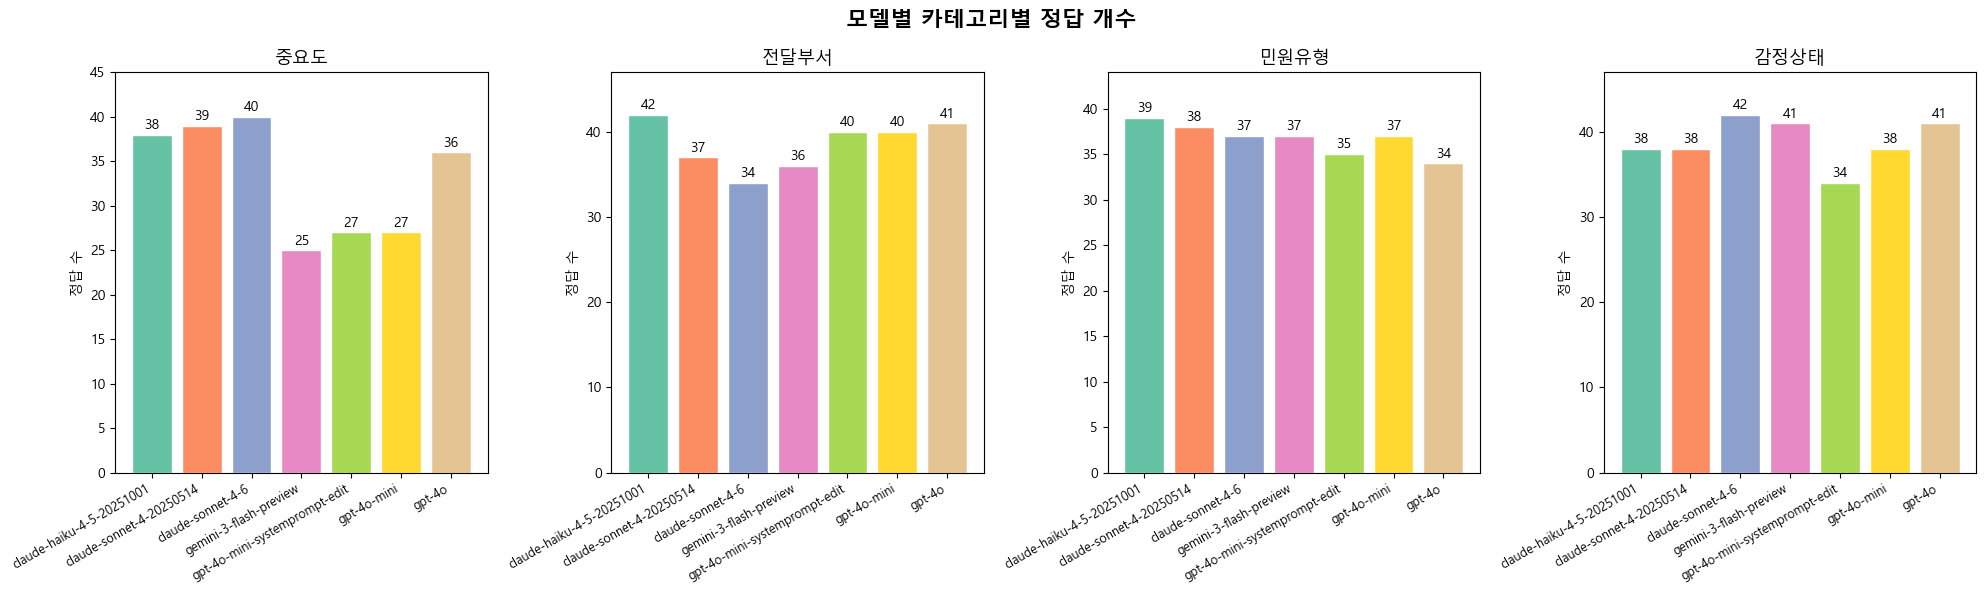


차트 저장: model_evaluation.png


In [45]:
#모델별 각 카테고리 별 정답 개수 barplot으로 시각화

# ── 시각화 ──────────────────────────────────────────────
models = list(results.keys())
n_models = len(models)
n_cats = len(CATEGORIES)

fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 6), sharey=False)
fig.suptitle("모델별 카테고리별 정답 개수", fontsize=16, fontweight="bold")

colors = plt.cm.Set2.colors

for ax, cat in zip(axes, CATEGORIES):
    values = [results[m][cat] for m in models]
    bars = ax.bar(range(n_models), values, color=colors[:n_models], edgecolor="white")
    ax.set_title(cat, fontsize=13)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("정답 수")
    ax.set_ylim(0, max(values) + 5 if max(values) > 0 else 10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(val), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("./2.ModelSelection/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n차트 저장: model_evaluation.png")

# 실전 데이터 생성 진행

In [59]:
# 랜덤 셔플한 dataframe 생성
# df_original = pd.read_csv("mayor_hope_cleaned.csv")
# df = df_original.sample(frac=1).reset_index(drop=True)
# df.to_csv('mayor_hope_labeled.csv', index=False)

In [24]:
#진행시켜.
df = pd.read_csv("mayor_hope_labeled.csv")
run_chain(df, "mayor_hope_labeled.csv")

[2411/13184] 완료: importance='높음' department='시민건강국' complaint_type='건의' emotion='중립'
[2412/13184] 완료: importance='보통' department='교통실' complaint_type='건의' emotion='중립'
[2413/13184] 완료: importance='낮음' department='분류 보류' complaint_type='항의' emotion='부정'
[2414/13184] 완료: importance='높음' department='주택실' complaint_type='항의' emotion='부정'
[2415/13184] 완료: importance='보통' department='주택실' complaint_type='건의' emotion='중립'
--- 2415건 중간 저장 완료 ---
[2416/13184] 완료: importance='보통' department='경제실' complaint_type='건의' emotion='중립'
[2417/13184] 완료: importance='높음' department='재난안전실' complaint_type='항의' emotion='부정'
[2418/13184] 완료: importance='보통' department='교통실' complaint_type='건의' emotion='부정'
[2419/13184] 완료: importance='높음' department='주택실' complaint_type='항의' emotion='부정'
[2420/13184] 완료: importance='높음' department='교통실' complaint_type='항의' emotion='부정'
--- 2420건 중간 저장 완료 ---
[2421/13184] 완료: importance='높음' department='주택실' complaint_type='항의' emotion='부정'
[2422/13184] 완료: importance='높음' de

KeyboardInterrupt: 

In [27]:
len(df) - df['assistant'].isnull().sum()

np.int64(2505)

# 저장

In [28]:
from huggingface_hub import login

login(token=os.getenv('HF_TOKEN'))
from datasets import Dataset


dataset = Dataset.from_pandas(df)
dataset.push_to_hub("leejunho12316/seoul-mayor-hope-labeled-backup2500", private=True)
print("HuggingFace 업로드 완료")

C:\Users\User\PycharmProjects\LLM_FineTuning_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  7.57ba/s]
Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (0 / 1):   2%|▏         |  525kB / 22.9MB,  327kB/s  
Processing Files (0 / 1):   5%|▍         | 1.05MB / 22.9MB,  477kB/s  
Processing Files (0 / 1):   9%|▉         | 2.10MB / 22.9MB,  874kB/s  
Processing Files (0 / 1):  14%|█▍        | 3.15MB / 22.9MB, 1.21MB/s  
Processing Files (0 / 1):  30%|██▉       | 6.83MB 

HuggingFace 업로드 완료
